In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
import joblib
import tkinter as tk
from tkinter import filedialog, messagebox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
import joblib
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

In [6]:
import h5py

# First, let's see the EXACT top-level keys
with h5py.File('cfd_weights.weights.h5', 'r') as f:
    print("Top-level keys:")
    for key in f.keys():
        print(repr(key))  # repr() shows exact characters including backslashe

Top-level keys:
'_layer_checkpoint_dependencies\\batch_normalization'
'_layer_checkpoint_dependencies\\batch_normalization_2'
'_layer_checkpoint_dependencies\\batch_normalization_4'
'_layer_checkpoint_dependencies\\dense'
'_layer_checkpoint_dependencies\\dense_2'
'_layer_checkpoint_dependencies\\dense_4'
'_layer_checkpoint_dependencies\\dense_6'
'_layer_checkpoint_dependencies\\dropout'
'_layer_checkpoint_dependencies\\dropout_1'
'_layer_checkpoint_dependencies\\dropout_2'
'metrics\\mean'
'metrics\\mean_metric_wrapper'
'optimizer'
'vars'


In [7]:
import h5py
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input
import joblib

# ── Step 1: Extract weights using FLAT keys ──────────────────────────────────

weights_map = {}

with h5py.File('cfd_weights.weights.h5', 'r') as f:
    layer_names = ['dense', 'batch_normalization', 'dense_2', 
                   'batch_normalization_2', 'dense_4', 
                   'batch_normalization_4', 'dense_6']
    
    for layer_name in layer_names:
        flat_key = f'_layer_checkpoint_dependencies\\{layer_name}'
        group = f[flat_key]
        if 'vars' in group:
            vars_group = group['vars']
            weights_map[layer_name] = [
                vars_group[str(i)][:] 
                for i in range(len(vars_group))
            ]
            print(f"✅ {layer_name}: {[w.shape for w in weights_map[layer_name]]}")

# ── Step 2: Rebuild model ────────────────────────────────────────────────────

model = Sequential([
    Input(shape=(6,)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(2, activation='linear')
])

model.build(input_shape=(None, 6))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# ── Step 3: Set weights layer by layer ──────────────────────────────────────

layer_order = [
    'dense',                  # Dense(256)
    'batch_normalization',    # BN 1
    'dense_2',                # Dense(128)
    'batch_normalization_2',  # BN 2
    'dense_4',                # Dense(64)
    'batch_normalization_4',  # BN 3
    'dense_6',                # Dense(2) output
]

# Only layers that have weights (skip Dropout)
trainable_layers = [l for l in model.layers if len(l.get_weights()) > 0]

for keras_layer, saved_name in zip(trainable_layers, layer_order):
    w = weights_map[saved_name]
    keras_layer.set_weights(w)
    print(f"✅ Loaded: {keras_layer.name} ← {saved_name} {[x.shape for x in w]}")

# ── Step 4: Load scaler + verify ─────────────────────────────────────────────

scaler = joblib.load('scaler.save')

dummy = np.zeros((1, 6))
dummy_scaled = scaler.transform(dummy)
pred = model.predict(dummy_scaled, verbose=0)

print("\n✅ Model loaded successfully — no retraining needed!")
print("Test prediction:", pred)

✅ dense: [(6, 256), (256,)]
✅ batch_normalization: [(256,), (256,), (256,), (256,)]
✅ dense_2: [(256, 128), (128,)]
✅ batch_normalization_2: [(128,), (128,), (128,), (128,)]
✅ dense_4: [(128, 64), (64,)]
✅ batch_normalization_4: [(64,), (64,), (64,), (64,)]
✅ dense_6: [(64, 2), (2,)]
✅ Loaded: dense_4 ← dense [(6, 256), (256,)]
✅ Loaded: batch_normalization_3 ← batch_normalization [(256,), (256,), (256,), (256,)]
✅ Loaded: dense_5 ← dense_2 [(256, 128), (128,)]
✅ Loaded: batch_normalization_4 ← batch_normalization_2 [(128,), (128,), (128,), (128,)]
✅ Loaded: dense_6 ← dense_4 [(128, 64), (64,)]
✅ Loaded: batch_normalization_5 ← batch_normalization_4 [(64,), (64,), (64,), (64,)]
✅ Loaded: dense_7 ← dense_6 [(64, 2), (2,)]

✅ Model loaded successfully — no retraining needed!
Test prediction: [[0.28242996 0.06842552]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.1.post1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


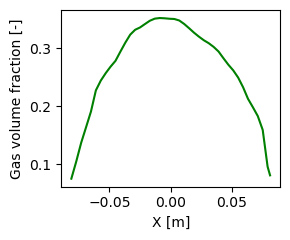

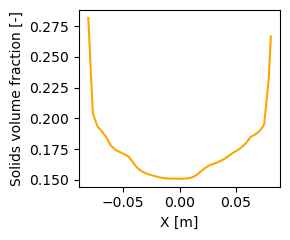

In [8]:
x_values = None
mean_gvof_values = None
mean_svof_values = None

input_names = ["ug(m/s)", "Cv(%)", "P(MPa)", "x(m)", "y(m)", "z(m)"]
output_names = ["Gas Volume Fraction", "Solid Volume Fraction"]

root = tk.Tk()
root.title("SBCR-CFD-DNN GUI")

# --- Top: Centered Conditions label ---
info_label = tk.Label(
    root,
    text=(
        "Conditions:\n"
        "X = -0.081 m to 0.081 m\n"
        "Y = 0 m to 1.75 m\n"
        "Z = -0.081 m to 0.081 m\n"
        "Cv = 9.1 vol.% to 25 vol.%\n"
        "ug = 0.08 m/s to 0.3 m/s\n"
        "P = 0.1 MPa to 1 MPa"
    ),
    fg='blue',
    font=('Arial', 12, 'bold'),
    justify='center'
)
info_label.grid(row=0, column=0, columnspan=4, padx=20, pady=8, sticky='n')

# --- Inputs: all in leftmost columns, starting row=1 ---
input_entries = []
for i, name in enumerate(input_names):
    label = tk.Label(root, text=name, anchor='w')
    label.grid(row=i+1, column=0, padx=6, pady=3, sticky='w')
    entry = tk.Entry(root, width=14)
    entry.grid(row=i+1, column=1, padx=6, pady=3, sticky='w')
    input_entries.append(entry)

# --- Output labels below inputs ---
output_labels = []
for i, name in enumerate(output_names):
    label = tk.Label(root, text=f"{name}: --", fg='red', font=('Arial', 12))
    label.grid(row=len(input_names)+1+i, column=0, columnspan=2, pady=4, sticky='w')
    output_labels.append(label)

# --- Buttons for prediction and Excel ---
btn_predict = tk.Button(root, text="Predict from Inputs", command=lambda: predict_from_inputs())
btn_predict.grid(row=len(input_names)+3, column=0, columnspan=2, pady=7, sticky='w')

btn_load_excel = tk.Button(root, text="Load Excel and Predict", command=lambda: load_excel_and_predict())
btn_load_excel.grid(row=len(input_names)+4, column=0, columnspan=2, pady=4, sticky='w')

btn_plot_gvof = tk.Button(root, text="Plot X vs GVOF", command=lambda: plot_x_vs_gvof())
btn_plot_gvof.grid(row=len(input_names)+5, column=0, pady=8, sticky='w')

btn_plot_svof = tk.Button(root, text="Plot X vs SVOF", command=lambda: plot_x_vs_svof())
btn_plot_svof.grid(row=len(input_names)+5, column=1, pady=8, sticky='w')

# --- Plot Frames: right side, upper for GVOF, lower for SVOF ---
plot_frame_gvof = tk.Frame(root, bd=2, relief='groove')
plot_frame_gvof.grid(row=1, column=3, rowspan=6, padx=15, pady=8, sticky='n')

plot_frame_svof = tk.Frame(root, bd=2, relief='groove')
plot_frame_svof.grid(row=7, column=3, rowspan=6, padx=15, pady=8, sticky='n')

# --- Logic Functions ---
def predict_from_inputs():
    try:
        inputs = [float(entry.get()) for entry in input_entries]
        inputs_scaled = scaler.transform(np.array(inputs).reshape(1, -1))
        prediction = model.predict(inputs_scaled)[0]
        for j in range(2):
            output_labels[j].config(text=f"{output_names[j]}: {prediction[j]:.4f}")
    except Exception as e:
        messagebox.showerror("Prediction Error", str(e))

def load_excel_and_predict():
    global x_values, mean_gvof_values, mean_svof_values
    try:
        file_path = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx;*.xls;*.csv")])
        if not file_path:
            return
        if file_path.endswith(('.xlsx', '.xls')):
            df = pd.read_excel(file_path)
        else:
            df = pd.read_csv(file_path)
        if df.shape[1] != 6:
            messagebox.showerror("Error", "Input file must have exactly 6 columns for input features.")
            return
        inputs_scaled = scaler.transform(df.values)
        predictions = model.predict(inputs_scaled)
        x_values = df.iloc[:, 3].values  # Safer index instead of name
        mean_gvof_values = predictions[:, 0]
        mean_svof_values = predictions[:, 1]
        messagebox.showinfo("Loaded", "Excel loaded and predictions ready for plotting.")
    except Exception as e:
        messagebox.showerror("Error", str(e))

def plot_x_vs_gvof():
    for widget in plot_frame_gvof.winfo_children():
        widget.destroy()
    fig, ax = plt.subplots(figsize=(3, 2.5))
    ax.plot(x_values, mean_gvof_values, color='green')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Gas volume fraction [-]')
    fig.tight_layout()
    canvas = FigureCanvasTkAgg(fig, master=plot_frame_gvof)
    canvas.draw()
    canvas.get_tk_widget().pack()

def plot_x_vs_svof():
    for widget in plot_frame_svof.winfo_children():
        widget.destroy()
    fig, ax = plt.subplots(figsize=(3, 2.5))
    ax.plot(x_values, mean_svof_values, color='orange')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Solids volume fraction [-]')
    fig.tight_layout()
    canvas = FigureCanvasTkAgg(fig, master=plot_frame_svof)
    canvas.draw()
    canvas.get_tk_widget().pack()

root.mainloop()